Checkpoint: /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int64/version_0/checkpoints/epoch=44-step=10530.ckpt
Prediction H5: /home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep45_bs64_in8_int64_test_predictions.h5
Output directory: /home/apaudel/NuGraph/scripts/plots_merged1_July3_tpc_pds_ep45_bs64_in8_int64

Event classes from checkpoint:
  index 0: cc_nue
  index 1: es_nue

Resolved mapping:
  CC index: 0 -> cc_nue
  ES index: 1 -> es_nue

Therefore probability columns are interpreted as:
  prob_block[:, 0] = P(CC)
  prob_block[:, 1] = P(ES)

Run directory: /home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int64/version_0

Available scalar tags:
  lr-AdamW
  loss/train
  event/loss-train
  event/recall-train
  event/precision-train
  temperature/event
  epoch
  loss/val
  event/loss-val
  event/recall-val
  event/precision-val

Available image tags:
  event/recall-matrix-val
  event/precision-matrix-val


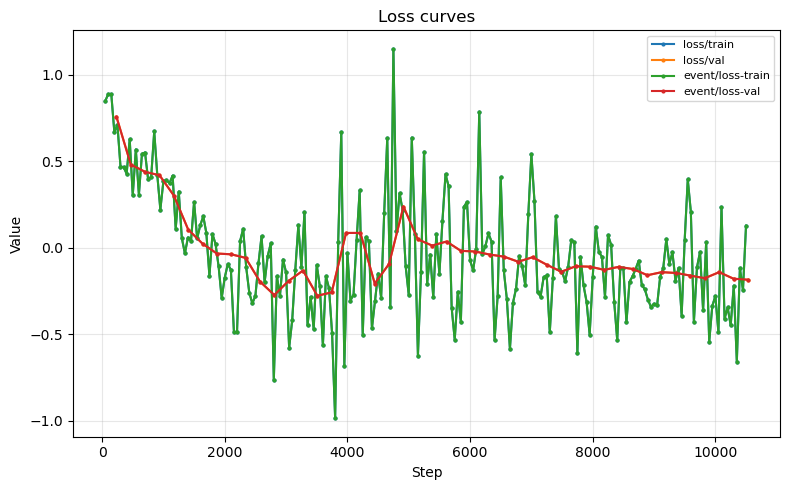

Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July3_tpc_pds_ep45_bs64_in8_int64/loss_curves.png


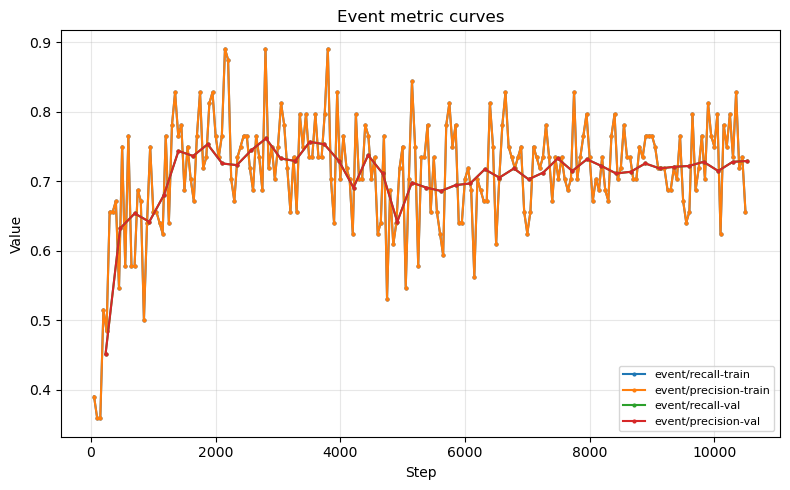

Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July3_tpc_pds_ep45_bs64_in8_int64/event_metric_curves.png


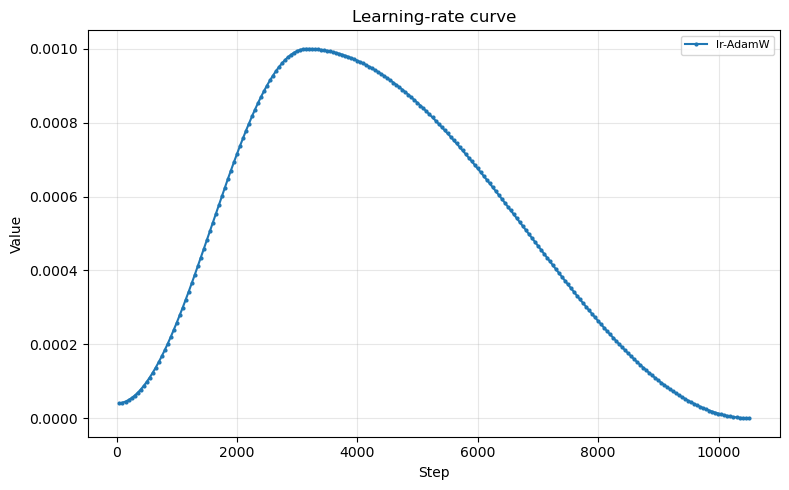

Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July3_tpc_pds_ep45_bs64_in8_int64/learning_rate_curve.png

TensorBoard image tags:
  event/recall-matrix-val
  event/precision-matrix-val
Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July3_tpc_pds_ep45_bs64_in8_int64/event_recall-matrix-val_latest.png


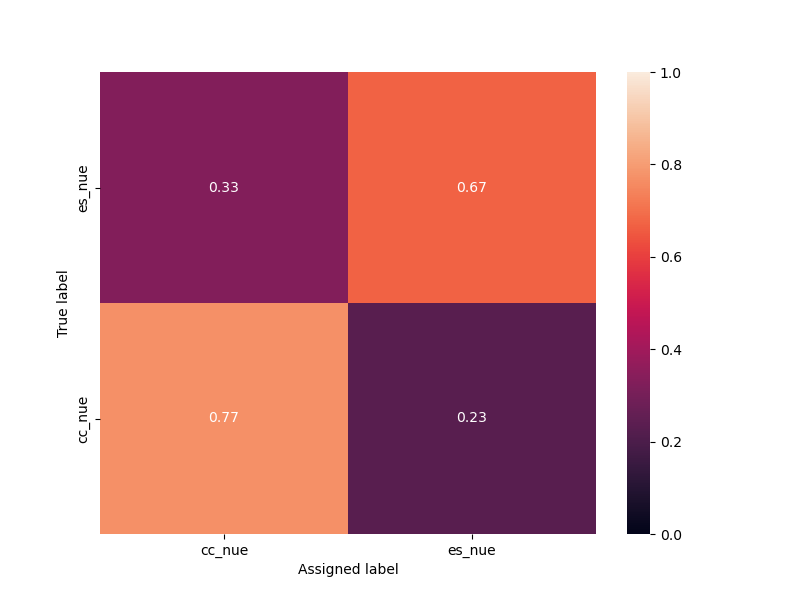

Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July3_tpc_pds_ep45_bs64_in8_int64/event_precision-matrix-val_latest.png


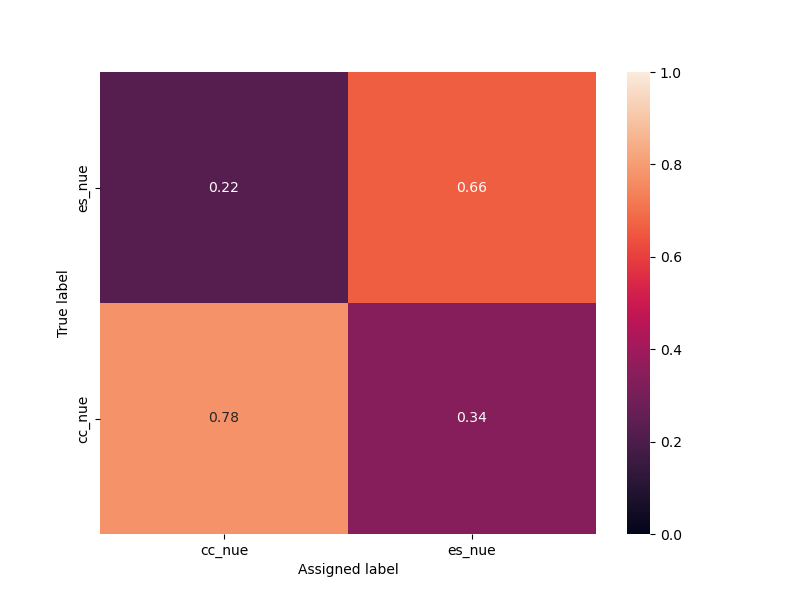


H5 tree:
  events -> Group 
  events/_i_table -> Group 
  events/_i_table/index -> Group 
  events/_i_table/index/abounds -> Dataset (0,)
  events/_i_table/index/bounds -> Dataset (0, 127)
  events/_i_table/index/indices -> Dataset (0, 131072)
  events/_i_table/index/indicesLR -> Dataset (131072,)
  events/_i_table/index/mbounds -> Dataset (0,)
  events/_i_table/index/mranges -> Dataset (0,)
  events/_i_table/index/ranges -> Dataset (0, 2)
  events/_i_table/index/sorted -> Dataset (0, 131072)
  events/_i_table/index/sortedLR -> Dataset (131201,)
  events/_i_table/index/zbounds -> Dataset (0,)
  events/table -> Dataset (835,)

/events/table is a Dataset
table shape: (835,)
table dtype: [('index', '<i8'), ('values_block_0', '<i8', (5,)), ('values_block_1', '<f8', (2,))]
table fields: ('index', 'values_block_0', 'values_block_1')

Loaded blocks:
  int_block shape : (835, 5)
  prob_block shape: (835, 2)

First few rows of int_block:


,0,1,2,3,4
0,20000172,172,8593,0,0
1,20000011,11,528,0,1
2,20000200,200,9999,0,0
3,20000176,176,8790,0,0
4,20000171,171,8536,0,0



First few rows of prob_block:


,0,1
0,0.860079,0.139921
1,0.445667,0.554333
2,0.913779,0.086221
3,0.712342,0.287658
4,0.501614,0.498386



Prediction file shapes:
  int_block : (835, 5)
  prob_block: (835, 2)
  y_true    : (835,)
  y_pred    : (835,)

Unique y_true values: (array([0, 1]), array([488, 347]))
Unique y_pred values: (array([0, 1]), array([479, 356]))

Final TEST confusion matrix counts
Rows = True [CC, ES], Columns = Pred [ES, CC]


,Pred ES,Pred CC
True CC,98,390
True ES,258,89



Final TEST confusion matrix row fractions


,Pred ES,Pred CC
True CC,0.200820,0.799180
True ES,0.743516,0.256484


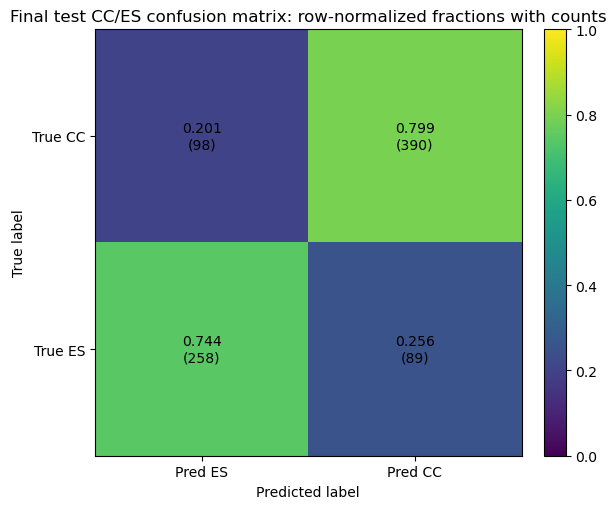

Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July3_tpc_pds_ep45_bs64_in8_int64/test_confusion_matrix_fraction_counts.png

Summary:


,N_test,accuracy,CC_true,ES_true,CC_to_CC,CC_to_ES,ES_to_ES,ES_to_CC,CC_efficiency,ES_efficiency,Avg P(CC) true CC,Avg P(ES) true ES,Avg wrong P(ES) true CC,Avg wrong P(CC) true ES
0,835,0.776048,488,347,390,98,258,89,0.79918,0.743516,0.660353,0.615279,0.339647,0.384721


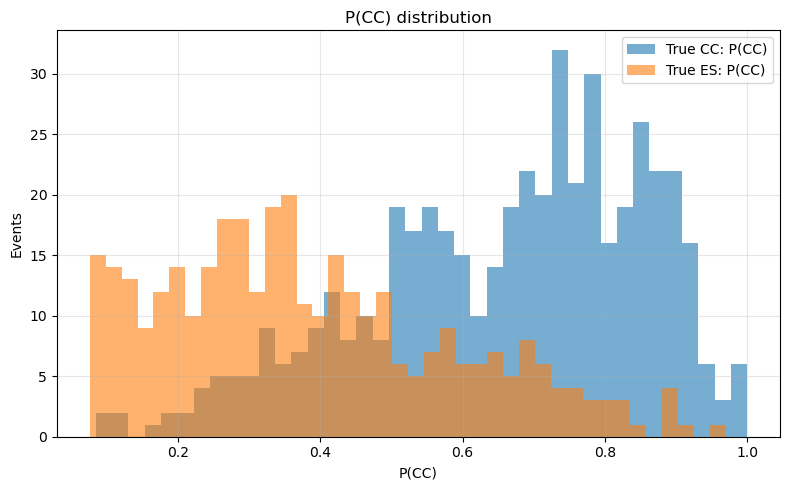

Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July3_tpc_pds_ep45_bs64_in8_int64/pcc_distribution.png


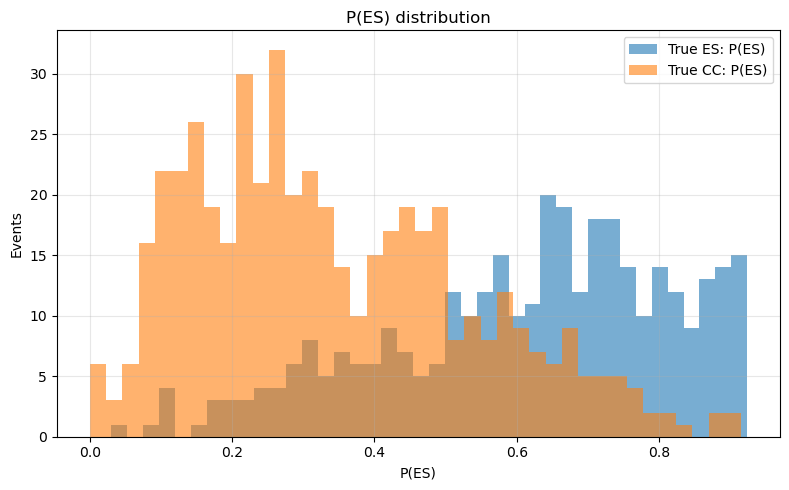

Saved: /home/apaudel/NuGraph/scripts/plots_merged1_July3_tpc_pds_ep45_bs64_in8_int64/pes_distribution.png

Done. All plots saved in:
/home/apaudel/NuGraph/scripts/plots_merged1_July3_tpc_pds_ep45_bs64_in8_int64


In [3]:
# NuGraph CC/ES plotting cell
# Corrected for:
#   1) event_classes order from checkpoint, not hard-coded
#   2) /events/table being either HDF5 Dataset or Group
#   3) final test confusion matrix from prediction H5
#   4) TensorBoard scalar/image plots from checkpoint run directory

import os
import glob
import h5py
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


# =============================================================================
# EDIT THESE PATHS IF NEEDED
# =============================================================================

CKPT = "/home/apaudel/NuGraph/logs/merged1_July3_tpc_pds_ep45_bs64_in8_int64/version_0/checkpoints/epoch=44-step=10530.ckpt"

PRED_H5 = "/home/apaudel/NuGraph/scripts/merged1_July3_tpc_pds_ep45_bs64_in8_int64_test_predictions.h5"

OUTDIR = "/home/apaudel/NuGraph/scripts/plots_merged1_July3_tpc_pds_ep45_bs64_in8_int64"
os.makedirs(OUTDIR, exist_ok=True)


# =============================================================================
# Helper functions
# =============================================================================

def safe_torch_load(path):
    try:
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        return torch.load(path, map_location="cpu")


def flatten_dict(d, prefix=""):
    out = {}
    if not isinstance(d, dict):
        return out

    for k, v in d.items():
        key = f"{prefix}.{k}" if prefix else str(k)
        if isinstance(v, dict):
            out.update(flatten_dict(v, key))
        else:
            out[key] = v

    return out


def get_event_classes_from_ckpt(ckpt_path):
    ckpt = safe_torch_load(ckpt_path)
    hp = ckpt.get("hyper_parameters", {})
    flat_hp = flatten_dict(hp)

    event_classes = None

    for k, v in flat_hp.items():
        if "event_classes" in k.lower():
            event_classes = list(v)
            break

    if event_classes is None:
        print("Checkpoint hyper_parameters keys:")
        for k in flat_hp:
            print(" ", k)
        raise RuntimeError("Could not find event_classes in checkpoint hyper_parameters.")

    return event_classes, ckpt, hp


def resolve_cc_es_indices(event_classes):
    cc_candidates = [
        i for i, name in enumerate(event_classes)
        if "cc" in str(name).lower()
    ]

    es_candidates = [
        i for i, name in enumerate(event_classes)
        if "es" in str(name).lower()
    ]

    if len(cc_candidates) != 1 or len(es_candidates) != 1:
        raise RuntimeError(
            f"Could not uniquely resolve CC/ES indices from event_classes={event_classes}"
        )

    return cc_candidates[0], es_candidates[0]


def get_run_dir_from_ckpt(ckpt_path):
    return os.path.dirname(os.path.dirname(ckpt_path))


def load_event_accumulator(run_dir):
    event_files = glob.glob(os.path.join(run_dir, "events.out.tfevents.*"))

    if not event_files:
        raise FileNotFoundError(f"No TensorBoard event files found in {run_dir}")

    ea = EventAccumulator(run_dir, size_guidance={"scalars": 0, "images": 0})
    ea.Reload()
    return ea


def scalar_to_df(ea, tag):
    vals = ea.Scalars(tag)
    return pd.DataFrame({
        "step": [v.step for v in vals],
        "value": [v.value for v in vals],
        "wall_time": [v.wall_time for v in vals],
        "tag": tag,
    })


def plot_scalar_group(ea, tags, title, outfile):
    available = ea.Tags().get("scalars", [])
    tags = [t for t in tags if t in available]

    if not tags:
        print(f"No scalar tags found for: {title}")
        return

    plt.figure(figsize=(8, 5))

    for tag in tags:
        df = scalar_to_df(ea, tag)
        plt.plot(
            df["step"],
            df["value"],
            marker="o",
            markersize=2,
            linewidth=1.5,
            label=tag,
        )

    plt.xlabel("Step")
    plt.ylabel("Value")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(outfile, dpi=200)
    plt.show()

    print("Saved:", outfile)


def save_latest_tensorboard_images(ea, outdir):
    image_tags = ea.Tags().get("images", [])

    if not image_tags:
        print("\nNo TensorBoard image tags found.")
        return

    print("\nTensorBoard image tags:")
    for tag in image_tags:
        print(" ", tag)

    for tag in image_tags:
        imgs = ea.Images(tag)
        if not imgs:
            continue

        latest = imgs[-1]
        safe_name = tag.replace("/", "_").replace(" ", "_")
        outfile = os.path.join(outdir, f"{safe_name}_latest.png")

        with open(outfile, "wb") as f:
            f.write(latest.encoded_image_string)

        print("Saved:", outfile)
        display(Image(filename=outfile))


def print_h5_tree(path):
    print("\nH5 tree:")
    with h5py.File(path, "r") as f:
        def visitor(name, obj):
            shape = obj.shape if hasattr(obj, "shape") else ""
            print(f"  {name} -> {type(obj).__name__} {shape}")
        f.visititems(visitor)


def extract_block_from_compound_table(table, field):
    arr = np.asarray(table[field])

    # If field is object-like or list-like, vstack helps.
    try:
        arr2 = np.vstack(arr)
    except Exception:
        arr2 = np.asarray(arr)

    if arr2.ndim == 1:
        arr2 = arr2.reshape(-1, 1)

    return arr2


def load_predictions_h5(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Prediction file not found: {path}")

    print_h5_tree(path)

    with h5py.File(path, "r") as f:
        if "events" not in f:
            raise RuntimeError("No /events group found in prediction H5.")

        if "table" not in f["events"]:
            raise RuntimeError("No /events/table found in prediction H5.")

        obj = f["events"]["table"]

        # ---------------------------------------------------------------------
        # Case 1: /events/table is a Dataset
        # This is the case that caused your error.
        # ---------------------------------------------------------------------
        if isinstance(obj, h5py.Dataset):
            print("\n/events/table is a Dataset")

            table = np.array(obj)
            print("table shape:", table.shape)
            print("table dtype:", table.dtype)

            if table.dtype.names is None:
                raise RuntimeError(
                    "/events/table is a plain dataset, not a compound table. "
                    "Need manual inspection."
                )

            print("table fields:", table.dtype.names)

            if "values_block_0" not in table.dtype.names:
                raise RuntimeError(f"values_block_0 not found. Fields: {table.dtype.names}")

            if "values_block_1" not in table.dtype.names:
                raise RuntimeError(f"values_block_1 not found. Fields: {table.dtype.names}")

            int_block = extract_block_from_compound_table(table, "values_block_0")
            prob_block = extract_block_from_compound_table(table, "values_block_1")

        # ---------------------------------------------------------------------
        # Case 2: /events/table is a Group
        # This was the earlier assumption.
        # ---------------------------------------------------------------------
        elif isinstance(obj, h5py.Group):
            print("\n/events/table is a Group")
            print("Prediction table keys:", list(obj.keys()))

            int_block = np.asarray(obj["values_block_0"])
            prob_block = np.asarray(obj["values_block_1"])

            if int_block.ndim == 1:
                int_block = int_block.reshape(-1, 1)
            if prob_block.ndim == 1:
                prob_block = prob_block.reshape(-1, 1)

        else:
            raise RuntimeError(f"Unexpected /events/table object type: {type(obj)}")

    print("\nLoaded blocks:")
    print("  int_block shape :", int_block.shape)
    print("  prob_block shape:", prob_block.shape)

    print("\nFirst few rows of int_block:")
    display(pd.DataFrame(int_block[:5]))

    print("\nFirst few rows of prob_block:")
    display(pd.DataFrame(prob_block[:5]))

    # Earlier inspection of your prediction files showed:
    #   y_true = last-2 integer column
    #   y_pred = last-1 integer column
    if int_block.shape[1] < 2:
        raise RuntimeError(
            f"int_block has only {int_block.shape[1]} columns; cannot take last-2 and last-1."
        )

    y_true = int_block[:, -2].astype(int)
    y_pred = int_block[:, -1].astype(int)

    return y_true, y_pred, int_block, prob_block


def make_confusion_matrix(y_true, y_pred, cc_idx, es_idx):
    # Axis requested:
    #   rows    = True CC, True ES
    #   columns = Pred ES, Pred CC

    cm = np.zeros((2, 2), dtype=int)

    cm[0, 0] = np.sum((y_true == cc_idx) & (y_pred == es_idx))  # true CC -> pred ES
    cm[0, 1] = np.sum((y_true == cc_idx) & (y_pred == cc_idx))  # true CC -> pred CC

    cm[1, 0] = np.sum((y_true == es_idx) & (y_pred == es_idx))  # true ES -> pred ES
    cm[1, 1] = np.sum((y_true == es_idx) & (y_pred == cc_idx))  # true ES -> pred CC

    return cm


def row_normalize(cm):
    denom = cm.sum(axis=1, keepdims=True)
    return np.divide(cm, denom, out=np.zeros_like(cm, dtype=float), where=denom != 0)


def plot_confusion_matrix(cm, outfile, title="CC/ES confusion matrix"):
    cm_frac = row_normalize(cm)

    fig, ax = plt.subplots(figsize=(6.5, 5.2))
    im = ax.imshow(cm_frac, vmin=0, vmax=1)

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Pred ES", "Pred CC"])

    ax.set_yticks([0, 1])
    ax.set_yticklabels(["True CC", "True ES"])

    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(title)

    for i in range(2):
        for j in range(2):
            ax.text(
                j,
                i,
                f"{cm_frac[i, j]:.3f}\n({cm[i, j]})",
                ha="center",
                va="center",
            )

    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.savefig(outfile, dpi=200)
    plt.show()

    print("Saved:", outfile)


# =============================================================================
# 1. Read checkpoint and class mapping
# =============================================================================

event_classes, ckpt, hp = get_event_classes_from_ckpt(CKPT)
cc_idx, es_idx = resolve_cc_es_indices(event_classes)

print("=" * 90)
print("Checkpoint:", CKPT)
print("Prediction H5:", PRED_H5)
print("Output directory:", OUTDIR)
print("=" * 90)

print("\nEvent classes from checkpoint:")
for i, name in enumerate(event_classes):
    print(f"  index {i}: {name}")

print("\nResolved mapping:")
print("  CC index:", cc_idx, "->", event_classes[cc_idx])
print("  ES index:", es_idx, "->", event_classes[es_idx])

print("\nTherefore probability columns are interpreted as:")
print(f"  prob_block[:, {cc_idx}] = P(CC)")
print(f"  prob_block[:, {es_idx}] = P(ES)")


# =============================================================================
# 2. TensorBoard scalar plots and saved images from checkpoint run directory
# =============================================================================

RUN_DIR = get_run_dir_from_ckpt(CKPT)
print("\nRun directory:", RUN_DIR)

ea = load_event_accumulator(RUN_DIR)

scalar_tags = ea.Tags().get("scalars", [])
image_tags = ea.Tags().get("images", [])

print("\nAvailable scalar tags:")
for tag in scalar_tags:
    print(" ", tag)

print("\nAvailable image tags:")
for tag in image_tags:
    print(" ", tag)


loss_tags = [
    "loss/train",
    "loss/val",
    "loss/test",
    "event/loss-train",
    "event/loss-val",
    "event/loss-test",
]

plot_scalar_group(
    ea,
    loss_tags,
    "Loss curves",
    os.path.join(OUTDIR, "loss_curves.png"),
)


metric_keywords = [
    "accuracy",
    "acc",
    "precision",
    "recall",
    "f1",
    "efficiency",
    "auc",
]

metric_tags = [
    tag for tag in scalar_tags
    if any(word in tag.lower() for word in metric_keywords)
]

plot_scalar_group(
    ea,
    metric_tags,
    "Event metric curves",
    os.path.join(OUTDIR, "event_metric_curves.png"),
)


lr_tags = [
    tag for tag in scalar_tags
    if "lr" in tag.lower()
]

plot_scalar_group(
    ea,
    lr_tags,
    "Learning-rate curve",
    os.path.join(OUTDIR, "learning_rate_curve.png"),
)


# This saves TensorBoard images such as precision/recall matrices.
# Note: these are validation images from TensorBoard, not necessarily final test confusion matrices.
save_latest_tensorboard_images(ea, OUTDIR)


# =============================================================================
# 3. Final confusion matrix and probability summaries from prediction H5
# =============================================================================

y_true, y_pred, int_block, prob_block = load_predictions_h5(PRED_H5)

print("\nPrediction file shapes:")
print("  int_block :", int_block.shape)
print("  prob_block:", prob_block.shape)
print("  y_true    :", y_true.shape)
print("  y_pred    :", y_pred.shape)

print("\nUnique y_true values:", np.unique(y_true, return_counts=True))
print("Unique y_pred values:", np.unique(y_pred, return_counts=True))

if prob_block.shape[1] < len(event_classes):
    raise RuntimeError(
        f"prob_block has {prob_block.shape[1]} columns but checkpoint has "
        f"{len(event_classes)} event classes: {event_classes}"
    )

p_cc = prob_block[:, cc_idx]
p_es = prob_block[:, es_idx]

cm = make_confusion_matrix(y_true, y_pred, cc_idx, es_idx)
cm_frac = row_normalize(cm)

print("\nFinal TEST confusion matrix counts")
print("Rows = True [CC, ES], Columns = Pred [ES, CC]")

cm_df = pd.DataFrame(
    cm,
    index=["True CC", "True ES"],
    columns=["Pred ES", "Pred CC"],
)
display(cm_df)

print("\nFinal TEST confusion matrix row fractions")

cm_frac_df = pd.DataFrame(
    cm_frac,
    index=["True CC", "True ES"],
    columns=["Pred ES", "Pred CC"],
)
display(cm_frac_df)

plot_confusion_matrix(
    cm,
    os.path.join(OUTDIR, "test_confusion_matrix_fraction_counts.png"),
    title="Final test CC/ES confusion matrix: row-normalized fractions with counts",
)


# =============================================================================
# 4. Summary table
# =============================================================================

n_total = len(y_true)
accuracy = np.mean(y_true == y_pred)

n_true_cc = np.sum(y_true == cc_idx)
n_true_es = np.sum(y_true == es_idx)

cc_to_cc = np.sum((y_true == cc_idx) & (y_pred == cc_idx))
cc_to_es = np.sum((y_true == cc_idx) & (y_pred == es_idx))

es_to_es = np.sum((y_true == es_idx) & (y_pred == es_idx))
es_to_cc = np.sum((y_true == es_idx) & (y_pred == cc_idx))

cc_eff = cc_to_cc / n_true_cc if n_true_cc else np.nan
es_eff = es_to_es / n_true_es if n_true_es else np.nan

summary = pd.DataFrame([{
    "N_test": n_total,
    "accuracy": accuracy,

    "CC_true": n_true_cc,
    "ES_true": n_true_es,

    "CC_to_CC": cc_to_cc,
    "CC_to_ES": cc_to_es,

    "ES_to_ES": es_to_es,
    "ES_to_CC": es_to_cc,

    "CC_efficiency": cc_eff,
    "ES_efficiency": es_eff,

    "Avg P(CC) true CC": np.mean(p_cc[y_true == cc_idx]) if n_true_cc else np.nan,
    "Avg P(ES) true ES": np.mean(p_es[y_true == es_idx]) if n_true_es else np.nan,

    "Avg wrong P(ES) true CC": np.mean(p_es[y_true == cc_idx]) if n_true_cc else np.nan,
    "Avg wrong P(CC) true ES": np.mean(p_cc[y_true == es_idx]) if n_true_es else np.nan,
}])

print("\nSummary:")
display(summary)


# =============================================================================
# 5. Probability distribution plots
# =============================================================================

plt.figure(figsize=(8, 5))
plt.hist(p_cc[y_true == cc_idx], bins=40, alpha=0.6, label="True CC: P(CC)")
plt.hist(p_cc[y_true == es_idx], bins=40, alpha=0.6, label="True ES: P(CC)")
plt.xlabel("P(CC)")
plt.ylabel("Events")
plt.title("P(CC) distribution")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

pcc_out = os.path.join(OUTDIR, "pcc_distribution.png")
plt.savefig(pcc_out, dpi=200)
plt.show()
print("Saved:", pcc_out)


plt.figure(figsize=(8, 5))
plt.hist(p_es[y_true == es_idx], bins=40, alpha=0.6, label="True ES: P(ES)")
plt.hist(p_es[y_true == cc_idx], bins=40, alpha=0.6, label="True CC: P(ES)")
plt.xlabel("P(ES)")
plt.ylabel("Events")
plt.title("P(ES) distribution")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

pes_out = os.path.join(OUTDIR, "pes_distribution.png")
plt.savefig(pes_out, dpi=200)
plt.show()
print("Saved:", pes_out)


print("\nDone. All plots saved in:")
print(OUTDIR)